In [10]:
# ------- GPU Setup -------
import torch
assert torch.cuda.is_available(), "GPU not connected! Go to Runtime > Change runtime type > select GPU"
device = torch.device('cuda')
print(f"Connected to: {torch.cuda.get_device_name(0)}")
input('Any Key to continute')

Connected to: NVIDIA RTX PRO 6000 Blackwell Server Edition
Any Key to continute


''

In [11]:
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import TensorDataset, DataLoader

# ------- Helper Functions (from HelpersJSS.py) -------
def savePicInSequence(figure, folder_path):
    os.makedirs(folder_path, exist_ok=True)
    existing_files = os.listdir(folder_path)
    if not existing_files:
        next_num = 1
    else:
        numbers = [int(file_name[:-4]) for file_name in existing_files]
        next_num = np.max(numbers) + 1
    filename = f"{next_num:03d}.png"
    save_path = os.path.join(folder_path, filename)
    figure.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure as {filename}")

def text_box_to_fig(fig, hyper_params):
    ax = fig.gca()
    text = "\n".join(f"{key}: {value}" for key, value in hyper_params.items())
    num_params = len(hyper_params)
    text_height = 0.03 * num_params
    bottom_margin = text_height + 0.1
    fig.subplots_adjust(bottom=bottom_margin)
    fig.text(0.5, 0.01, text, ha='center', va='bottom', multialignment='left',
             fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ------- Hyper Parameters -------
HP = {
    'fig_path': 'Figs',
    'activation_function': nn.ELU,
    'loss_function': nn.MSELoss(),
    'optimizer_class': torch.optim.AdamW,
    'trajectory_limit': 2048,
    'train_batch_size': 1024,
    'test_batch_size': 100,
    'autoencoder_layers': [7, 32, 64, 128],
    'k_init_std': 0.01,
    'objective_alphas': [0.5, 0.75, 1.75],
    'decay_alpha_ae': 1e-4,
    'lr_ae': 1e-3,
    'epochs_ae': 200,
    'lr_full': 1e-4,
    'epochs_full': 20000,
    'decay_alpha_full': 1e-4,
}

In [12]:
# ------- Data Prep -------
# Upload kdata.txt to Colab first, or mount Google Drive
ntraj = 2148  # number of trajectories
nt = 50  # number of time steps
ny = 7  # number of states
assert HP['autoencoder_layers'][0] == ny, 'Failed: autoencoder_layers[0] == ny'
assert HP['trajectory_limit'] <= ntraj - 100, 'Failed: trajectory_limit <= ntraj - 100'
assert HP['trajectory_limit'] >= HP['train_batch_size'], 'Failed: trajectory_limit >= train_batch_size'

tvec = np.linspace(0, 350, nt)
Y = np.loadtxt('kdata.txt').reshape(ntraj, nt, ny)
Ytrain = Y[:HP['trajectory_limit'], :, :]
Ytest = Y[2048:, :, :]
print(f'Loaded data:\n    Ytrain size: {Ytrain.shape}\n    Ytest shape {Ytest.shape}')
print('    Shape: trajectories (trial runs), time steps, states')

Ytrain_torch = torch.tensor(Ytrain, dtype=torch.float32).to(device)
Ytest_torch = torch.tensor(Ytest, dtype=torch.float32).to(device)

train_dataset = TensorDataset(Ytrain_torch)
train_loader = DataLoader(train_dataset, batch_size=HP['train_batch_size'], shuffle=True)
test_dataset = TensorDataset(Ytest_torch)
test_loader = DataLoader(test_dataset, batch_size=HP['test_batch_size'], shuffle=False)

Loaded data:
    Ytrain size: (2048, 50, 7)
    Ytest shape (100, 50, 7)
    Shape: trajectories (trial runs), time steps, states


In [13]:
# ------- Net Creations -------
class Encoder(nn.Module):
    def __init__(self, layer_list, activation):
        super().__init__()
        layers = []
        for i in range(len(layer_list) - 1):
            layers.append(nn.Linear(layer_list[i], layer_list[i+1]))
            if i < len(layer_list) - 2:
                layers.append(activation())
        self.encoder = nn.Sequential(*layers)
    def forward(self, x):
        return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, layer_list, activation):
        super().__init__()
        layers = []
        for i in range(len(layer_list) - 1, 0, -1):
            layers.append(nn.Linear(layer_list[i], layer_list[i-1]))
            if i > 1:
                layers.append(activation())
        self.decoder = nn.Sequential(*layers)
    def forward(self, x):
        return self.decoder(x)

class KoopmanModel(nn.Module):
    def __init__(self, layer_list, activation, k_init_std):
        super().__init__()
        self.encoder = Encoder(layer_list, activation)
        self.decoder = Decoder(layer_list, activation)
        latent_dim = layer_list[-1]
        self.K = nn.Linear(latent_dim, latent_dim, bias=False)
        nn.init.normal_(self.K.weight, mean=0.0, std=k_init_std)

    def forward(self, x):  # x shape: [B, nt, ny]
        z = self.encoder(x)
        z_roll = z[:, 0:1, :]
        z = z[:, 1:, :]  # [B, nt-1, latent_dim]
        z_pred = []
        T = z.shape[1]
        for _ in range(T):
            z_roll = self.K(z_roll)
            z_pred.append(z_roll)
        z_pred = torch.cat(z_pred, dim=1)  # [B, nt-1, latent_dim]
        x_pred = self.decoder(z_pred)  # [B, nt-1, ny]
        return z, z_pred, x_pred

    def autoencode(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [14]:
# ------- Loss -------
def get_loss(model, traj_batch, loss_fn, alphas, train_AE_only=False):
    a1, a2, a3 = alphas
    recon = loss_fn(model.autoencode(traj_batch), traj_batch)
    if train_AE_only:
        return recon
    x = traj_batch[:, 1:, :]
    z, z_pred, x_pred = model(traj_batch)
    pred = loss_fn(x_pred, x)
    lin_dyn = loss_fn(z_pred, z)
    return a1*recon + a2*pred + a3*lin_dyn

# ------- Trainings -------
def train(model, loader, optimizer, loss_fn, alphas, train_AE_only=False):
    model.train()
    total_loss = 0.0
    for (traj_batch,) in loader:
        optimizer.zero_grad()
        loss = get_loss(model, traj_batch, loss_fn, alphas, train_AE_only)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, loss_fn, alphas, train_AE_only=False):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for (traj_batch,) in loader:
            loss = get_loss(model, traj_batch, loss_fn, alphas, train_AE_only)
            total_loss += loss.item()
    return total_loss / len(loader)

In [15]:
# ------- Instantiate Model (on GPU) -------
model = KoopmanModel(HP['autoencoder_layers'], HP['activation_function'], HP['k_init_std']).to(device)
print(f"Model on: {next(model.parameters()).device}")

Model on: cuda:0


Epoch 10: Train Loss: 0.187294, Test Loss: 0.179606
Epoch 20: Train Loss: 0.120335, Test Loss: 0.114333
Epoch 30: Train Loss: 0.041719, Test Loss: 0.038174
Epoch 40: Train Loss: 0.018998, Test Loss: 0.017047
Epoch 50: Train Loss: 0.006538, Test Loss: 0.006153
Epoch 60: Train Loss: 0.005040, Test Loss: 0.004845
Epoch 70: Train Loss: 0.004582, Test Loss: 0.004409
Epoch 80: Train Loss: 0.004292, Test Loss: 0.004144
Epoch 90: Train Loss: 0.004068, Test Loss: 0.003939
Epoch 100: Train Loss: 0.003884, Test Loss: 0.003771
Epoch 110: Train Loss: 0.003726, Test Loss: 0.003625
Epoch 120: Train Loss: 0.003585, Test Loss: 0.003494
Epoch 130: Train Loss: 0.003453, Test Loss: 0.003369
Epoch 140: Train Loss: 0.003325, Test Loss: 0.003247
Epoch 150: Train Loss: 0.003196, Test Loss: 0.003121
Epoch 160: Train Loss: 0.003062, Test Loss: 0.002989
Epoch 170: Train Loss: 0.002920, Test Loss: 0.002848
Epoch 180: Train Loss: 0.002770, Test Loss: 0.002696
Epoch 190: Train Loss: 0.002609, Test Loss: 0.002533
Ep

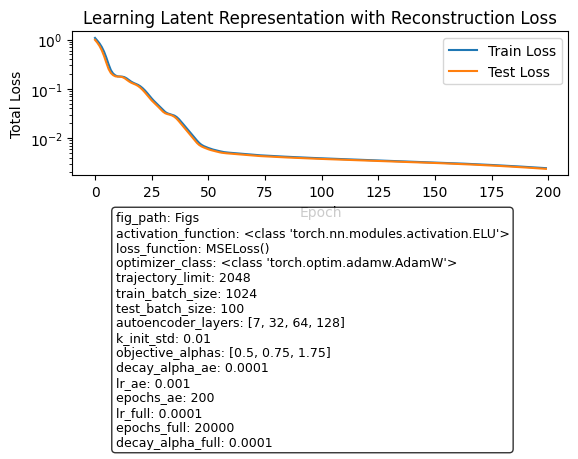

In [16]:
# ------- Phase 1: Learn Latent Representation (AE only) -------
for param in model.K.parameters():
    param.requires_grad = False

ae_optimizer = HP['optimizer_class'](
    list(model.encoder.parameters()) + list(model.decoder.parameters()),
    lr=HP['lr_ae'],
    weight_decay=HP['decay_alpha_ae']
)

train_losses = []
test_losses = []
for i in range(HP['epochs_ae']):
    train_loss = train(model, train_loader, ae_optimizer, HP['loss_function'], HP['objective_alphas'], train_AE_only=True)
    train_losses.append(train_loss)
    test_loss = evaluate(model, test_loader, HP['loss_function'], HP['objective_alphas'], train_AE_only=True)
    test_losses.append(test_loss)
    if (i+1) % 10 == 0:
        print(f'Epoch {i+1}: Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}')

fig = plt.figure()
plt.plot(range(HP['epochs_ae']), train_losses, label='Train Loss')
plt.plot(range(HP['epochs_ae']), test_losses, label='Test Loss')
plt.title('Learning Latent Representation with Reconstruction Loss')
plt.ylabel('Total Loss')
plt.xlabel('Epoch')
plt.legend()
plt.yscale('log')
text_box_to_fig(fig, HP)
savePicInSequence(fig, HP['fig_path'])
plt.show()

Epoch 100: Train Loss: 0.167072, Test Loss: 0.165854
Epoch 200: Train Loss: 0.145122, Test Loss: 0.144541
Epoch 300: Train Loss: 0.137989, Test Loss: 0.137488
Epoch 400: Train Loss: 0.134313, Test Loss: 0.133837
Epoch 500: Train Loss: 0.132185, Test Loss: 0.131737
Epoch 600: Train Loss: 0.130920, Test Loss: 0.130501
Epoch 700: Train Loss: 0.130144, Test Loss: 0.129745
Epoch 800: Train Loss: 0.129624, Test Loss: 0.129234
Epoch 900: Train Loss: 0.129238, Test Loss: 0.128849
Epoch 1000: Train Loss: 0.128924, Test Loss: 0.128534
Epoch 1100: Train Loss: 0.128654, Test Loss: 0.128261
Epoch 1200: Train Loss: 0.128412, Test Loss: 0.128015
Epoch 1300: Train Loss: 0.128190, Test Loss: 0.127789
Epoch 1400: Train Loss: 0.127981, Test Loss: 0.127579
Epoch 1500: Train Loss: 0.127793, Test Loss: 0.127362
Epoch 1600: Train Loss: 0.127609, Test Loss: 0.127179
Epoch 1700: Train Loss: 0.127493, Test Loss: 0.127081
Epoch 1800: Train Loss: 0.127622, Test Loss: 0.127088
Epoch 1900: Train Loss: 0.127418, Tes

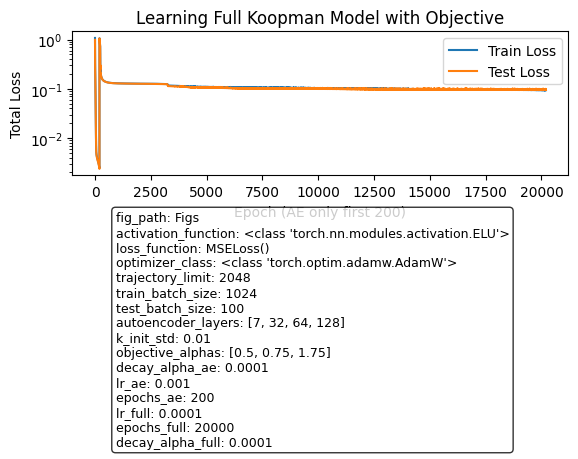

In [17]:
# ------- Phase 2: Learn Koopman Operator + Full Model -------
for param in model.K.parameters():
    param.requires_grad = True

full_optimizer = HP['optimizer_class'](
    model.parameters(),
    lr=HP['lr_full'],
    weight_decay=HP['decay_alpha_full']
)

for i in range(HP['epochs_full']):
    train_loss = train(model, train_loader, full_optimizer, HP['loss_function'], HP['objective_alphas'], train_AE_only=False)
    train_losses.append(train_loss)
    test_loss = evaluate(model, test_loader, HP['loss_function'], HP['objective_alphas'], train_AE_only=False)
    test_losses.append(test_loss)
    if (i+1) % 100 == 0:
        print(f'Epoch {i+1}: Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}')

fig = plt.figure()
plt.plot(range(HP['epochs_full'] + HP['epochs_ae']), train_losses, label='Train Loss')
plt.plot(range(HP['epochs_full'] + HP['epochs_ae']), test_losses, label='Test Loss')
plt.title('Learning Full Koopman Model with Objective')
plt.ylabel('Total Loss')
plt.xlabel(f"Epoch (AE only first {HP['epochs_ae']})")
plt.legend()
plt.yscale('log')
text_box_to_fig(fig, HP)
savePicInSequence(fig, HP['fig_path'])
plt.show()

Saved figure as 006.png


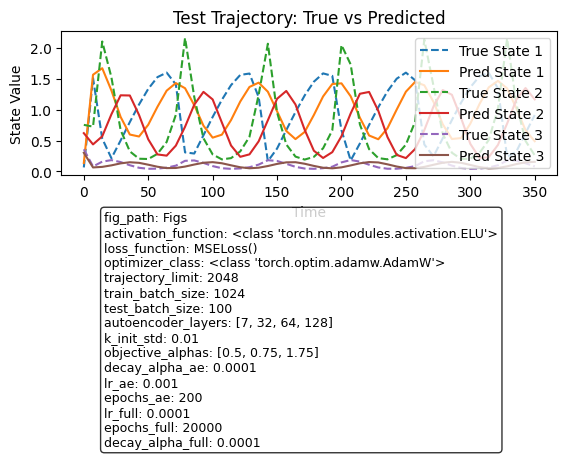

In [18]:
# ------- Plot First Test Trajectory -------
model.eval()

with torch.no_grad():
    x_true = Ytest_torch[0:1]  # (1, nt, ny)
    x_pred = torch.zeros_like(x_true)
    z_roll = model.encoder(x_true[:, 0:1, :])  # initial state only

    for t in range(nt):
        x_pred[:, t, :] = model.decoder(z_roll)
        z_roll = model.K(z_roll)

x_true_np = x_true.squeeze(0).cpu().numpy()
x_pred_np = x_pred.squeeze(0).cpu().numpy()

fig = plt.figure()
for i in range(3):
    plt.plot(tvec, x_true_np[:, i], '--', label=f'True State {i+1}')
    plt.plot(tvec, x_pred_np[:, i], '-', label=f'Pred State {i+1}')
plt.xlabel('Time')
plt.ylabel('State Value')
plt.title('Test Trajectory: True vs Predicted')
plt.legend()
text_box_to_fig(fig, HP)
savePicInSequence(fig, HP['fig_path'])
plt.show()